In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler  
from imblearn.over_sampling import RandomOverSampler
import shap
import joblib
from matplotlib import pyplot as plt
import seaborn as sns


2026-04-17 00:17:34.894340: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-17 00:17:34.904809: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 00:17:35.244089: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 00:17:37.037625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [ ]:
#load in different datasets
x_train_bal = pd.read_parquet('X_train_balanced.parquet', engine='fastparquet')
y_train_bal = pd.read_parquet('Y_train_balanced.parquet', engine= 'fastparquet')
x_train = pd.read_parquet('X_train.parquet', engine= 'fastparquet')
y_train = pd.read_parquet('Y_train.parquet', engine= 'fastparquet')
x_val = pd.read_parquet('X_val.parquet', engine='fastparquet')
y_val = pd.read_parquet('Y_val.parquet', engine='fastparquet')
x_test = pd.read_parquet('X_test.parquet', engine='fastparquet')
y_test = pd.read_parquet('Y_test.parquet', engine='fastparquet')

In [ ]:
#Set Binary Classifier
y_train['depression_sign_binary'] = y_train['depression_severity'].map({0:0, 1:1, 2:1})
y_test['depression_sign_binary'] = y_test['depression_severity'].map({0:0, 1:1, 2:1})
y_val['depression_sign_binary'] = y_val['depression_severity'].map({0:0, 1:1, 2:1})
y_train_bal['depression_sign_binary'] = y_train_bal['depression_severity'].map({0:0, 1:1, 2:1})

# y_train['depression_sign_binary'] = np.where(y_train['dpq_total'] >= 10, 1, 0)
# y_test['depression_sign_binary'] = np.where(y_test['dpq_total'] >= 10, 1, 0)
# y_val['depression_sign_binary'] = np.where(y_val['dpq_total'] >= 10, 1, 0)
# y_train_bal['depression_sign_binary'] = y_train_bal['depression_severity'].map({0:0, 1:0, 2:1})

In [ ]:
#Generate undersampled data
under_sampler = RandomUnderSampler(random_state=0)
x_train_under, y_train_under = under_sampler.fit_resample(x_train, y_train['depression_severity'])
x_train_under_bin, y_train_under_bin = under_sampler.fit_resample(x_train, y_train['depression_sign_binary'])
print("Shape of the undersampled training data:",x_train_under.shape)
print("Shape of the undersampled binar training data:",x_train_under_bin.shape)

Shape of the undersampled training data: (816, 146)
Shape of the undersampled binar training data: (1566, 146)


In [ ]:
#create upsampled binary data
ros = RandomOverSampler(sampling_strategy='not majority', random_state=7)
x_train_bal_bin, y_train_bal_bin = ros.fit_resample(x_train, y_train['depression_sign_binary'])
x_train_bal_bin.shape

(4514, 146)

SVM Accuracy: 0.7879684418145957
Classification report: 
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       776
           1       0.62      0.24      0.35       238

    accuracy                           0.79      1014
   macro avg       0.71      0.60      0.61      1014
weighted avg       0.76      0.79      0.75      1014



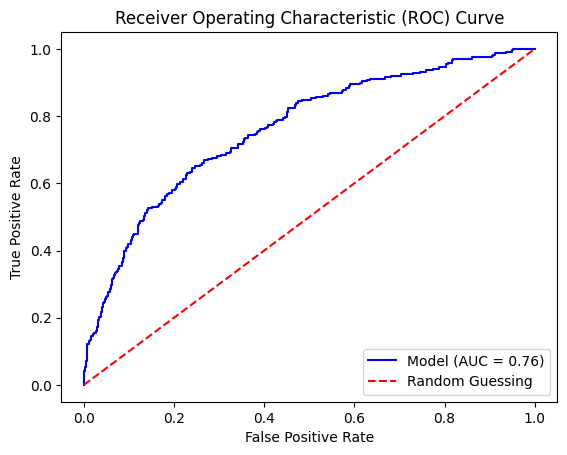

In [ ]:
#Create XGBoost Model from x_train data for binary label

model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.01,     
    max_depth=15,            
    n_estimators=300, 
    min_child_weight = 20,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='dart',    
    tree_method='auto',
    eval_metric = 'auc',
    random_state=0
)
model.fit(x_train, y_train['depression_sign_binary'])
y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)[:, 1]
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


SVM Accuracy: 0.727810650887574
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.76      0.81       776
           1       0.44      0.62      0.52       238

    accuracy                           0.73      1014
   macro avg       0.65      0.69      0.66      1014
weighted avg       0.77      0.73      0.74      1014



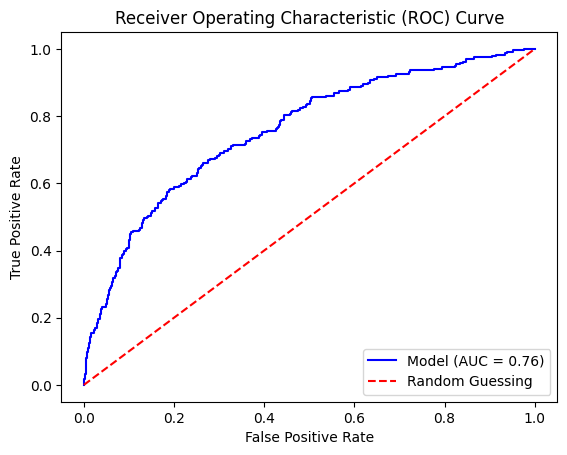

In [ ]:
#Create XGBoost Model from x_train data for binary label with class weight

model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.01,     
    max_depth=15,            
    n_estimators=300, 
    min_child_weight = 20,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='gbtree',    
    tree_method='auto',
    eval_metric = 'auc',
    scale_pos_weight = 2257/783,
    random_state=0
)
model.fit(x_train, y_train['depression_sign_binary'])
y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)[:, 1]
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

SVM Accuracy: 0.7337278106508875
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.77      0.82       776
           1       0.45      0.60      0.51       238

    accuracy                           0.73      1014
   macro avg       0.66      0.69      0.67      1014
weighted avg       0.77      0.73      0.75      1014



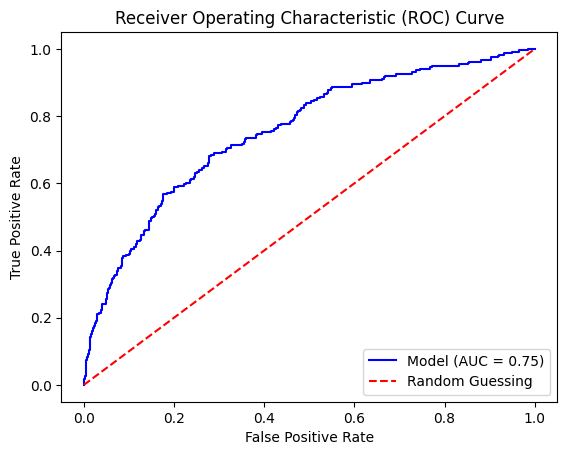

In [ ]:
#Create XGBoost Model from x_train upsampled data for binary label 
model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.01,     
    max_depth=8,            
    n_estimators=300, 
    min_child_weight = 20,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=1,              
    booster='gbtree',    
    tree_method='auto',
    eval_metric = 'auc',
    sampling_method = 'gradient_based',
    random_state=0
)
model.fit(x_train_bal_bin, y_train_bal_bin)
y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)[:, 1]
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

SVM Accuracy: 0.6923076923076923
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.70      0.78       776
           1       0.41      0.68      0.51       238

    accuracy                           0.69      1014
   macro avg       0.64      0.69      0.64      1014
weighted avg       0.77      0.69      0.71      1014



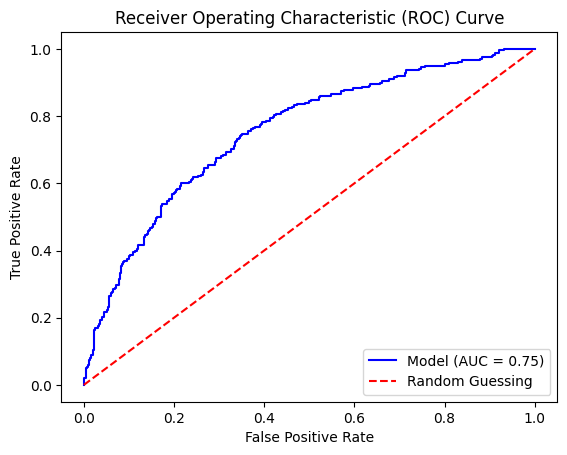

Best Threshold: 0.58
Best F1-score: 0.52
Classification report with optimized threshold: 
               precision    recall  f1-score   support

           0       0.86      0.78      0.82       776
           1       0.46      0.60      0.52       238

    accuracy                           0.74      1014
   macro avg       0.66      0.69      0.67      1014
weighted avg       0.77      0.74      0.75      1014



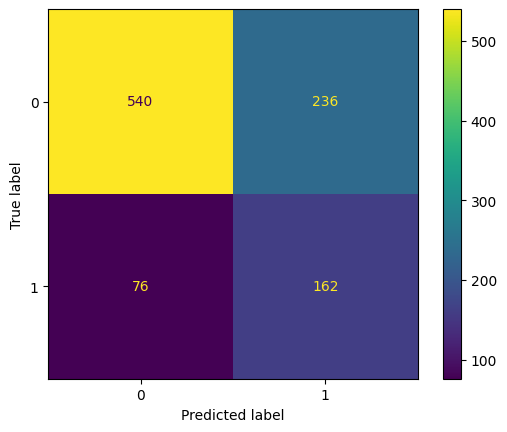

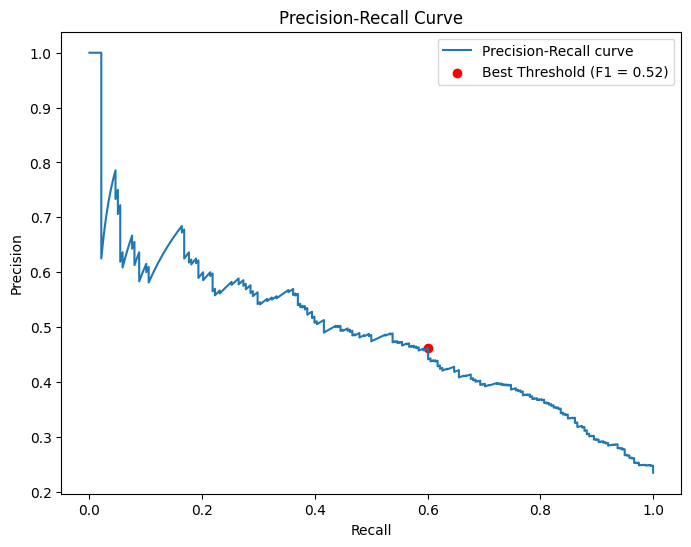

In [ ]:
#Create XGBoost Model from x_train undersampled data for binary label
model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.01,     
    max_depth=12,            
    n_estimators=300, 
    min_child_weight = 20,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=1,              
    booster='dart',    
    tree_method='auto',
    eval_metric = 'auc',
    sampling_method = 'gradient_based',
    random_state=0
)
model.fit(x_train_under_bin, y_train_under_bin)
y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)[:, 1]
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

cnf_matrix = confusion_matrix(np.array(y_test['depression_sign_binary']), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix)
disp.plot()
precision, recall, thresholds = precision_recall_curve(y_test['depression_sign_binary'], y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")
threshold = best_threshold
y_pred_thresh = (y_probs > threshold).astype(int)
print(f'Classification report with optimized threshold: \n {classification_report(y_test['depression_sign_binary'], y_pred_thresh)}')
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
# Plot the threshold points
plt.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.show()

SVM Accuracy: 0.7021696252465484
Val Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.73      0.79       739
           1       0.49      0.71      0.58       275

    accuracy                           0.72      1014
   macro avg       0.68      0.72      0.69      1014
weighted avg       0.77      0.72      0.73      1014

Test Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.71      0.78       776
           1       0.42      0.69      0.52       238

    accuracy                           0.70      1014
   macro avg       0.65      0.70      0.65      1014
weighted avg       0.77      0.70      0.72      1014



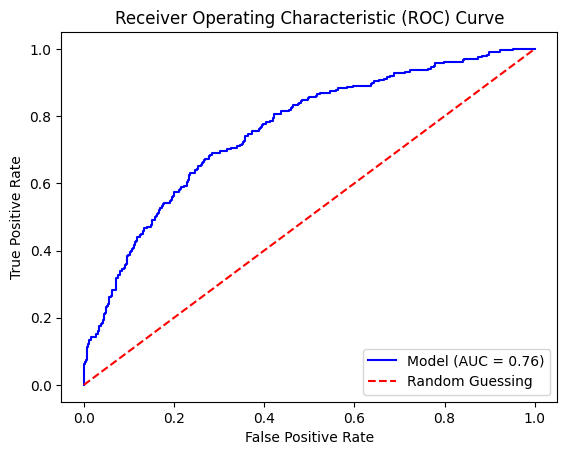

Best Threshold: 0.51
Best F1-score: 0.53
Classification report with optimized threshold: 
               precision    recall  f1-score   support

           0       0.88      0.72      0.79       776
           1       0.43      0.68      0.53       238

    accuracy                           0.71      1014
   macro avg       0.65      0.70      0.66      1014
weighted avg       0.77      0.71      0.73      1014



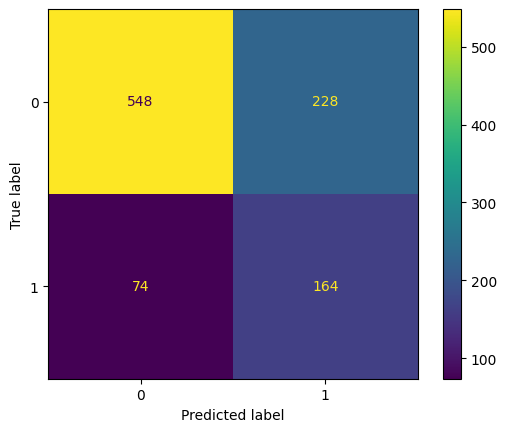

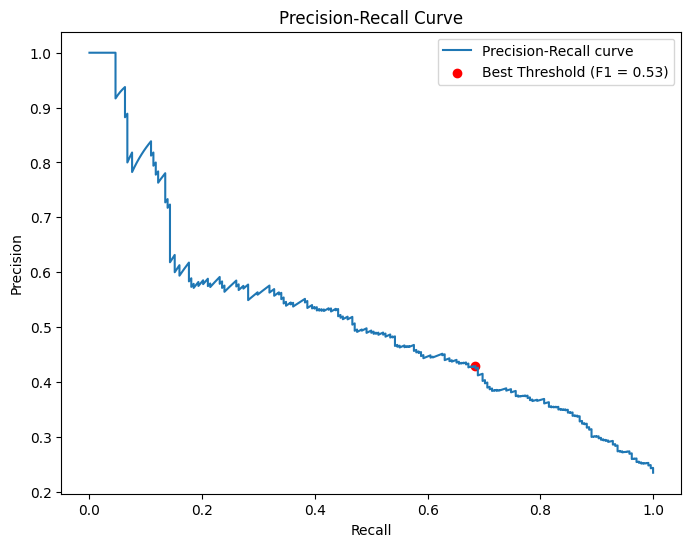

In [ ]:
#Create XGBoost Model from x_train undersampled data for binary label with tuned hyperparameters
model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.01,     
    max_depth=10,            
    n_estimators=300, 
    min_child_weight = 35,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=1,              
    booster='gbtree',    
    tree_method='auto',
    eval_metric = 'auc',
    sampling_method = 'gradient_based',
    random_state=0
)
model.fit(x_train_under_bin, y_train_under_bin)
y_pred = model.predict(x_test)
y_pred_val = model.predict(x_val)
y_probs = model.predict_proba(x_test)[:, 1]
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Val Classification report: \n {classification_report(y_val['depression_sign_binary'], y_pred_val)}')
print(f'Test Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

cnf_matrix = confusion_matrix(np.array(y_test['depression_sign_binary']), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix)
disp.plot()

joblib.dump(model, "XGB_best_model.pkl")
#Plot precision_recall curve to evaluate best threshold- since threshold of 0.51 is ideal and testing with this threshold yields
#the same results, threshold is not altered for predictions

precision, recall, thresholds = precision_recall_curve(y_test['depression_sign_binary'], y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")
threshold = best_threshold
y_pred_thresh = (y_probs > threshold).astype(int)
print(f'Classification report with optimized threshold: \n {classification_report(y_test['depression_sign_binary'], y_pred_thresh)}')
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
# Plot the threshold points
plt.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.show()

In [27]:
y_pred = model.predict(x_test, output_margin=True)
explainer = shap.TreeExplainer(model)
explanation = explainer(x_test)
shap_values = explanation.values

np.abs(shap_values.sum(axis=1) + explanation.base_values - y_pred).max()

np.float32(1.4305115e-06)

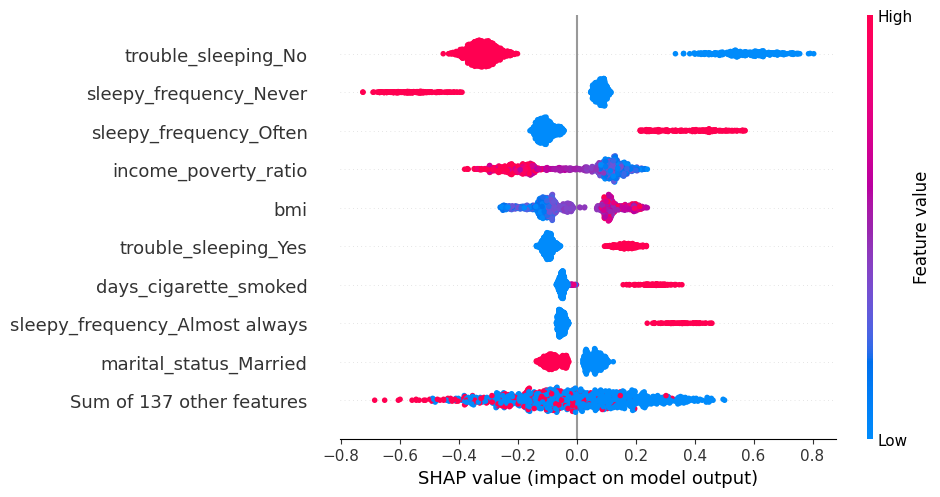

In [29]:
shap.plots.beeswarm(explanation)

# FNN Hyperparameter Tuning (Not used in paper)

In [13]:
#Create FNN model to be used for binary classification
def build_model_binary(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='Adam',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    #This keras random seed is necessary for reproducibility- should have been added to function
    keras.utils.set_random_seed(0)

    # YOUR CODE HERE
    optimizer_dic = {"SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate),
                     "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate)
                     }
    model = tf.keras.Sequential()
    j = 1
    model.add(tf.keras.Input(shape=(146,), name='Input'))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units=hidden_layer_size,
                                        activation=activation,
                                        name=f'Hidden_{j}'))
        model.add(tf.keras.layers.Dropout(0.4, name=f'Dropout_{j}')) 
        j+=1
    model.add(tf.keras.layers.Dense(units=n_classes, activation='sigmoid', name='Output'))
    model.compile(
        optimizer=optimizer_dic[optimizer],
        loss='binary_crossentropy',
        metrics=[metric] 
    )


    return model

E0000 00:00:1776033311.128218    7806 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776033311.136923    7806 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Training the x_train_under binary model...


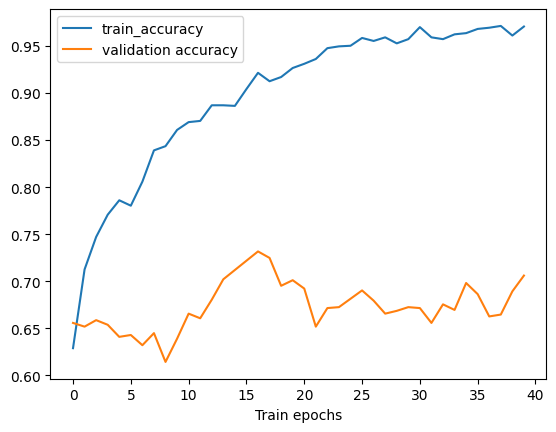

Training accuracy: 0.9706
Validation accuracy: 0.7061
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.83      0.70      0.76       776
           1       0.36      0.55      0.43       238

    accuracy                           0.66      1014
   macro avg       0.60      0.62      0.60      1014
weighted avg       0.72      0.66      0.68      1014

Best Threshold: 0.80
Best F1-score: 0.46


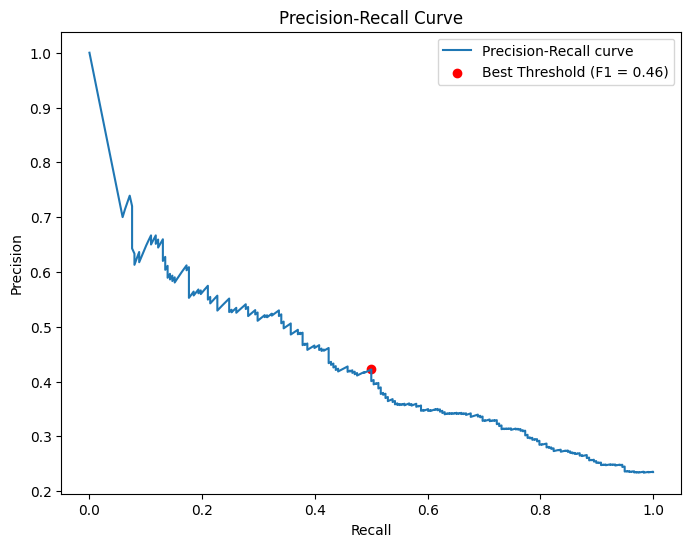

Classification report with optimized threshold: 
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       776
           1       0.42      0.50      0.45       238

    accuracy                           0.72      1014
   macro avg       0.63      0.64      0.63      1014
weighted avg       0.74      0.72      0.73      1014



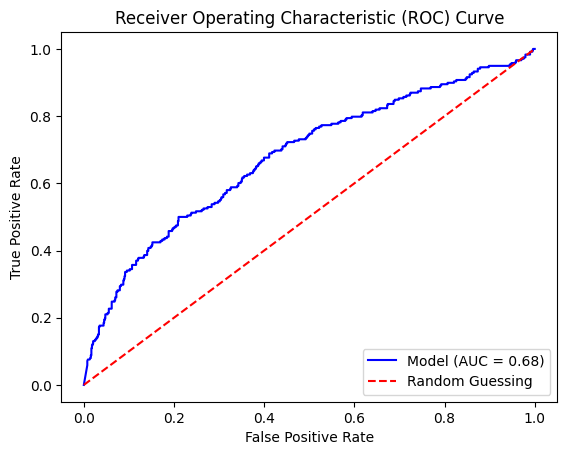

In [14]:
#Train FNN model on x_train_under data for binary classification
def train_and_evaluate_binary(data='x_train_under binary',
                       hidden_layer_sizes=[128],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.BinaryAccuracy(),
                       num_epochs=40):

  # Build the model.
    model = build_model_binary(n_classes=1,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train_under_bin
    X_val = x_val
    Y_train = y_train_under_bin
    Y_val = y_val['depression_sign_binary']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['binary_accuracy']
    val_accuracy = history.history['val_binary_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate_binary()
y_probs = model.predict(x_test)
y_pred = np.round(model.predict(x_test))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

precision, recall, thresholds = precision_recall_curve(y_test['depression_sign_binary'], y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
# Plot the threshold points
plt.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.show()

threshold = best_threshold
y_pred_thresh = (y_probs > threshold).astype(int)
print(f'Classification report with optimized threshold: \n {classification_report(y_test['depression_sign_binary'], y_pred_thresh)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Training the x_train_bal model...


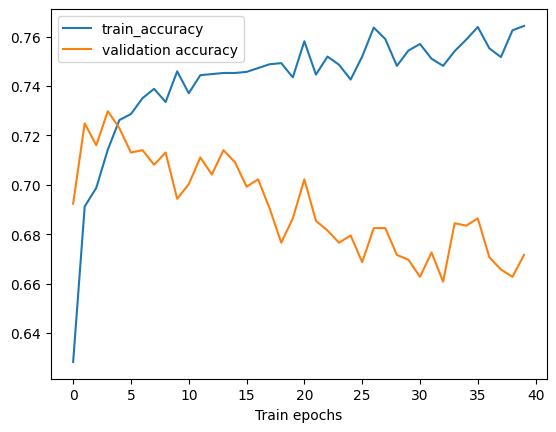

Training accuracy: 0.7643
Validation accuracy: 0.6716
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.65      0.74       776
           1       0.37      0.66      0.47       238

    accuracy                           0.65      1014
   macro avg       0.61      0.65      0.60      1014
weighted avg       0.74      0.65      0.68      1014

Best Threshold: 0.53
Best F1-score: 0.47


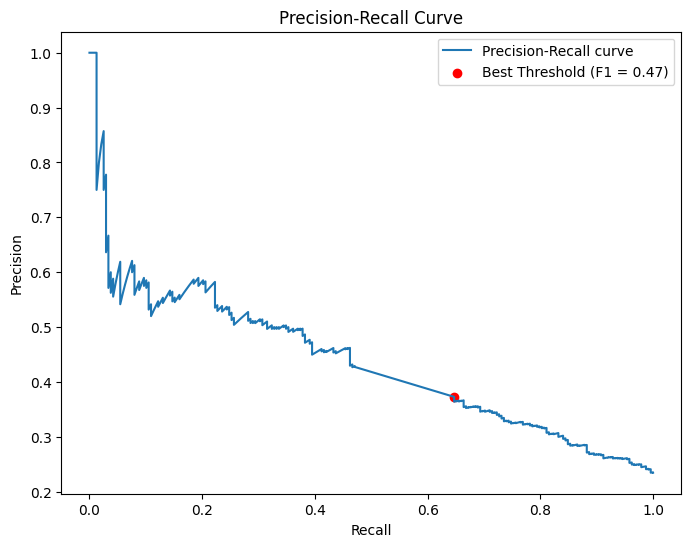

Classification report with optimized threshold: 
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       776
           1       0.43      0.47      0.45       238

    accuracy                           0.73      1014
   macro avg       0.63      0.64      0.63      1014
weighted avg       0.74      0.73      0.73      1014



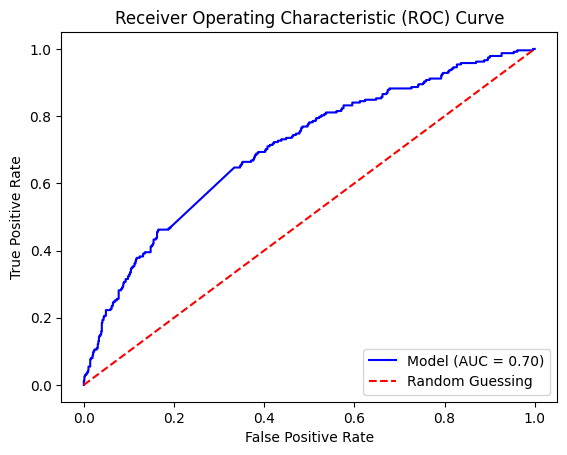

In [15]:
#Train FNN model on x_train_bal (upscaled) data for binary classification
def train_and_evaluate_binary(data='x_train_bal',
                       hidden_layer_sizes=[10],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.BinaryAccuracy(),
                       num_epochs=40):

  # Build the model.
    model = build_model_binary(n_classes=1,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train_bal_bin
    X_val = x_val
    Y_train = y_train_bal_bin
    Y_val = y_val['depression_sign_binary']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['binary_accuracy']
    val_accuracy = history.history['val_binary_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate_binary()
y_probs = model.predict(x_test)
y_pred = np.round(model.predict(x_test))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')


precision, recall, thresholds = precision_recall_curve(y_test['depression_sign_binary'], y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
# Plot the threshold points
plt.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.show()

threshold = best_threshold
y_pred_thresh = (y_probs > threshold).astype(int)
print(f'Classification report with optimized threshold: \n {classification_report(y_test['depression_sign_binary'], y_pred_thresh)}')

fpr, tpr, _ = metrics.roc_curve(y_test['depression_sign_binary'], y_probs)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



Best Threshold: 0.53
Best F1-score: 0.47


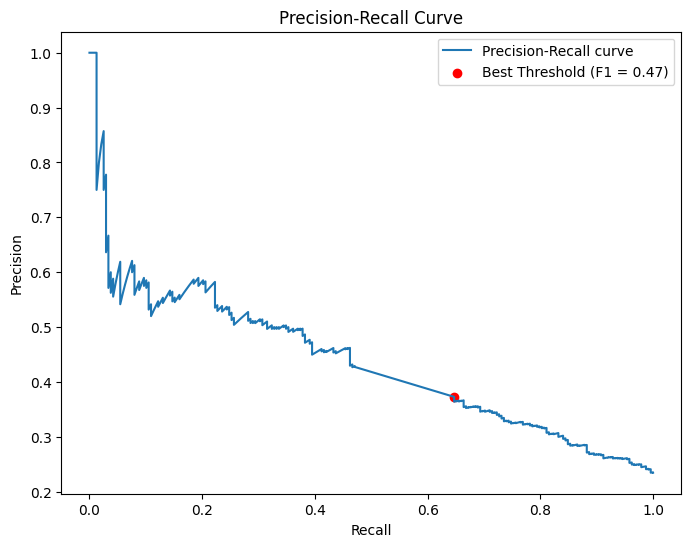

In [16]:
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
# Plot the threshold points
plt.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.show()